# Support Vector Regression (SVR)

## Importing the libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Importing the dataset

In [2]:
dataset = pd.read_csv('student-mat.csv')
X = dataset.iloc[:, 1:-1].values
y = dataset.iloc[:, -1].values

In [3]:
print(X)

[['F' 18 'U' ... 6 5 6]
 ['F' 18 'U' ... 6 5 6]
 ['F' 18 'U' ... 6 5 6]
 ...
 ['M' 21 'R' ... 3 10 8]
 ['M' 18 'R' ... 0 11 12]
 ['M' 19 'U' ... 5 8 9]]


In [4]:
print(y)

[ 6  7  8  9 10 11 12  6 19 15  9 12 14 11 16 14 14 10  5 10 15 15 16 12
  8  8 11 15 11 11 12 17 16 12 15  6 18 15 11 13 11 12 18 11  9  6 11 20
 14  7 13 13 10 11 13 10 15 15  9 16 11 11  9  9 10 15 12  6  8 16 15 10
  5 14 11 10 10 11 10  5 12 11  6 15 10  8  6 14 10  7  8 18  6 10 14 10
 15 10 14  8  5 17 14  6 18 11  8 18 13 16 19 10 13 19  9 16 14 13  8 13
 15 15 13 13  8 12 11  9  0 18  0  0 12 11  0  0  0  0 12 15  0  9 11 13
  0 11  0 11  0 10  0 14 10  0 12  8 13 10 15 12  0  7  0 10  7 12 10 16
  0 14  0 16 10  0  9  9 11  6  9 11  8 12 17  8 12 11 11 15  9 10 13  9
  8 10 14 15 16 10 18 10 16 10 10  6 11  9  7 13 10  7  8 13 14  8 10 15
  4  8  8 10  6  0 17 13 14  7 15 12  9 12 14 11  9 13  6 10 13 12 11  0
 12 12  0 12  0 18 13  8  5 15  8 10  8  8 12  8 13 11 14  0 18  8 12  9
  0 17 10 11 10  0  9 14 11 14 10 12  9  9  8 10  8 10 12 10 11 11 19 12
 14 15 11 15 13 18 14 11  0  8 14 16 11 10 14 18 13 12 18  8 12 10  0 13
 11 11 13 11  0  9 10 11 13  9 11 15 15 11 16 10  9

## One Hot Encoding

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [0, 2, 3, 4, 7, 8, 9, 10, 14, 15, 16, 17, 18, 19, 20, 21 ])], remainder='passthrough')
X = np.array(ct.fit_transform(X))

## Splitting the Dataset

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

## Feature Scaling

In [7]:
from sklearn.preprocessing import StandardScaler

sc_X = StandardScaler()
sc_y = StandardScaler()

X_train = sc_X.fit_transform(X_train)
X_test = sc_X.transform(X_test)

y_train = sc_y.fit_transform(y_train.reshape(-1, 1)).flatten()

## Training the SVR model on the training dataset

In [8]:
from sklearn.svm import SVR
regressor = SVR(kernel = 'rbf')
regressor.fit(X_train, y_train)

SVR()

## Predicting the Test set results

In [9]:
y_pred_scaled = regressor.predict(X_test)
y_pred = sc_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

print("Predicted values:")
print(y_pred)

print("Actual values:")
print(y_test)

Predicted values:
[13.28627038 11.56571099  9.27144334 15.30271437 16.02054326 12.58458086
 12.046098   11.31945696  9.53241124 13.19896741  7.59519228 10.55905685
 11.31020505  7.85280188 14.65231609 14.15336635 11.54010613  8.41544266
 10.57160474 14.21743543  7.7452296   6.8942469   6.22616086 12.69346749
 10.86171609 14.78138254 10.56364605 18.06475513  6.55468717 12.4824046
  3.2409525   8.63077596  7.98664854  6.7455884  14.14337959  9.66992065
 12.31273026 15.30807513  8.83334838  8.57139219  8.57139219 15.07161788
 10.55886507  7.17424107  9.92199013  7.40146356 12.42896268  6.79394607
 11.75005526  8.35329252  9.66433903 17.48542115 10.97941637 10.26850571
 11.93221775  9.60900513 10.85119376 11.78773733 13.55197472 13.05163386
 13.05865387 14.73251275 14.17970063 13.55546267 10.77243204  8.57139219
 14.86790575 11.74960035  8.89192718  9.54795205  9.53486279 15.06800603
  9.68607301  6.30869025 10.36330377  9.88341266 10.77590771 13.67257893
  7.60546054 11.08620581 10.231462

## Evaluating the model

In [10]:
from sklearn.metrics import r2_score, mean_absolute_error

print("R2 score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2 score: 0.5831874355150621
MAE: 2.213982515857834


## Feature Importance

In [11]:
from sklearn.inspection import permutation_importance

# Getting original feature names used in X
original_feature_names = dataset.columns[1:-1]

# Getting transformed feature names after one-hot encoding
encoded_feature_names = ct.get_feature_names_out(original_feature_names)

# Calculating permutation importance on the test set
perm_importance = permutation_importance(
    regressor,
    X_test,
    y_test,
    n_repeats=10,
    random_state=0,
    scoring='r2'
)

# Creating a dataframe
feature_importance = pd.DataFrame({
    'Feature': encoded_feature_names,
    'Importance': perm_importance.importances_mean
})

# Sorting by importance
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

print(feature_importance.head(15))

                   Feature  Importance
55           remainder__G2    0.130837
54           remainder__G1    0.069269
46     remainder__failures    0.015517
35      encoder__higher_no    0.010253
36     encoder__higher_yes    0.010253
53     remainder__absences    0.008709
41          remainder__age    0.005673
26  encoder__schoolsup_yes    0.005076
25   encoder__schoolsup_no    0.005076
49        remainder__goout    0.004870
51         remainder__Walc    0.003183
9     encoder__Mjob_health    0.002978
47       remainder__famrel    0.002690
10     encoder__Mjob_other    0.002481
17   encoder__Fjob_teacher    0.002450


## Plot Feature Importance

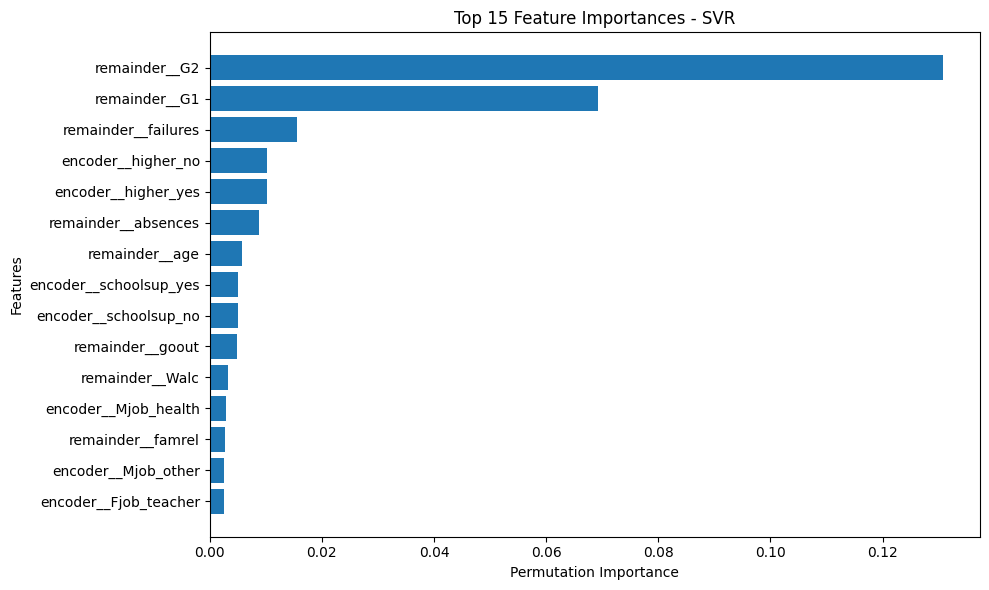

In [12]:
top_n = 15
top_features = feature_importance.head(top_n)

plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature'][::-1], top_features['Importance'][::-1])
plt.xlabel('Permutation Importance')
plt.ylabel('Features')
plt.title('Top 15 Feature Importances - SVR')
plt.tight_layout()
plt.show()